# Sentivity and replicability analysis of `MCube`

We first analyze the senesitivity of `MCube` to cell type deconvolution using the Visium data.
Specifically, we compare the results from `MCube` when integrting the estimated cell type proportions from two different methods (`RCTD` and `STitch3D`).
To examine whether the results are replicable, we then compare the results from `MCube` on the two slices of the Visium data.

In [1]:
set.seed(20250428)

library(Matrix)
library(spacexr)
library(MCube)

library(dplyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# RAW_DATA_PATH <- "/import/home/share/zw/data/mouse_brain"
RAW_DATA_PATH <- "/import/home/share/zw/pql/data/mouse_brain"
DATA_PATH <- "/import/home/share/zw/pql/data/mouse_brain/reliability"
RESULT_PATH <- "/import/home/share/zw/pql/results/mouse_brain/reliability"

if (!dir.exists(file.path(DATA_PATH, "visium_1"))) {
    dir.create(file.path(DATA_PATH, "visium_1"), recursive = TRUE)
}
if (!dir.exists(file.path(DATA_PATH, "visium_2"))) {
    dir.create(file.path(DATA_PATH, "visium_2"), recursive = TRUE)
}
if (!dir.exists(file.path(RESULT_PATH, "visium_1"))) {
    dir.create(file.path(RESULT_PATH, "visium_1"), recursive = TRUE)
}
if (!dir.exists(file.path(RESULT_PATH, "visium_2"))) {
    dir.create(file.path(RESULT_PATH, "visium_2"), recursive = TRUE)
}

In [3]:
# scRNA-seq reference data
sc_counts <- as.data.frame(readr::read_csv(
    file.path(RAW_DATA_PATH, "visium_1", "sc_counts.csv")
))
rownames(sc_counts) <- sc_counts[, 1]
sc_counts[, 1] <- NULL
sc_counts <- as.matrix(sc_counts)
dim(sc_counts)

sc_labels <- as.matrix(read.csv(
    file.path(RAW_DATA_PATH, "visium_1", "sc_labels.csv"),
    header = TRUE, row.names = 1
))[, 1]
# Exclude cells with unknown or low quality labels
# ex_cells <- grep("Unk|LowQ", sc_labels)
ex_cells <- which(sc_labels == "Unk_1")
sc_labels <- sc_labels[-ex_cells]
sc_labels <- factor(sc_labels, levels = unique(sc_labels))

sc_counts <- sc_counts[-ex_cells, ]

reference <- Reference(t(sc_counts), sc_labels, rowSums(sc_counts))

New names:
• `` -> `...1`
Rows: 40532 Columns: 6416
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr    (1): ...1
dbl (6415): 0610040J01Rik, 0610043K17Rik, 1110002J07Rik, 1110004F10Rik, 1110...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 40532  6415

Warning message in Reference(t(sc_counts), sc_labels, rowSums(sc_counts)):
“Reference: number of cells per cell type is 10819, larger than maximum allowable of 10000. Downsampling number of cells to: 10000”


## Visium Slice 1

In [4]:
counts <- as.data.frame(readr::read_csv(
    file.path(RAW_DATA_PATH, "visium_1", "counts.csv")
))
rownames(counts) <- counts[, 1]
counts[, 1] <- NULL
counts <- as.matrix(counts)
dim(counts)

coordinates <- as.data.frame(readr::read_csv(
    file.path(RAW_DATA_PATH, "visium_1", "3D_coordinates.csv")
))
rownames(coordinates) <- coordinates[, 1]
coordinates[, c(1, 4)] <- NULL
coordinates <- as.matrix(coordinates)
dim(coordinates)

puck <- SpatialRNA(as.data.frame(coordinates), t(counts), rowSums(counts))

New names:
• `` -> `...1`
Rows: 4168 Columns: 6416
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr    (1): ...1
dbl (6415): 0610040J01Rik, 0610043K17Rik, 1110002J07Rik, 1110004F10Rik, 1110...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 4168 6415

New names:
• `` -> `...1`
Rows: 4168 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): ...1
dbl (3): x, y, z

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 4168    2

### Integrating with `RCTD`

#### Cell type deconvolution

In [5]:
myRCTD <- create.RCTD(
    puck, reference,
    CELL_MIN_INSTANCE = 20, max_cores = 8
)
myRCTD <- run.RCTD(myRCTD, doublet_mode = "full")
saveRDS(myRCTD, file.path(RESULT_PATH, "visium_1", "myRCTD.rds"))

Begin: process_cell_type_info

process_cell_type_info: number of cells in reference: 38849

process_cell_type_info: number of genes in reference: 6415




       Ext_L23        Oligo_2 Astro_THAL_med        Inh_Sst          Inh_6 
          1244          10000            405            640            467 
      Ext_L5_3    Inh_Meis2_3          Micro       Ext_L5_2        Ext_Pir 
           127            789           1218            166            954 
     Astro_AMY          Inh_2          Inh_1      Inh_Pvalb      Inh_Lamp5 
           498            839            573            804            331 
       Ext_L25           Nb_2     Ext_Thal_1        Ext_L56      Ext_Unk_2 
           922            203           1197           1422            205 
     Ext_Unk_3          Inh_3      Ext_Amy_2     Ext_Thal_2       Ext_L5_1 
           416            818            797            671            893 
         OPC_1  Astro_AMY_CTX    Ext_Hpc_DG1     Astro_HYPO          Inh_4 
          1015            279            554            451           1389 
   Inh_Meis2_1    Ext_Hpc_DG2        Ext_Med    Inh_Meis2_2    Ext_Hpc_CA1 
           

End: process_cell_type_info

create.RCTD: getting regression differentially expressed genes: 

get_de_genes: Ext_L23 found DE genes: 112

get_de_genes: Oligo_2 found DE genes: 411

get_de_genes: Astro_THAL_med found DE genes: 353

get_de_genes: Inh_Sst found DE genes: 123

get_de_genes: Inh_6 found DE genes: 195

get_de_genes: Ext_L5_3 found DE genes: 134

get_de_genes: Inh_Meis2_3 found DE genes: 153

get_de_genes: Micro found DE genes: 647

get_de_genes: Ext_L5_2 found DE genes: 103

get_de_genes: Ext_Pir found DE genes: 69

get_de_genes: Astro_AMY found DE genes: 333

get_de_genes: Inh_2 found DE genes: 98

get_de_genes: Inh_1 found DE genes: 86

get_de_genes: Inh_Pvalb found DE genes: 131

get_de_genes: Inh_Lamp5 found DE genes: 166

get_de_genes: Ext_L25 found DE genes: 147

get_de_genes: Nb_2 found DE genes: 364

get_de_genes: Ext_Thal_1 found DE genes: 213

get_de_genes: Ext_L56 found DE genes: 157

get_de_genes: Ext_Unk_2 found DE genes: 151

get_de_genes: Ext_Unk_3 found DE ge

In [6]:
write.table(
    rownames(myRCTD@spatialRNA@counts),
    file = file.path(
        DATA_PATH, "visium_1",
        paste0("HVG_RCTD", ".csv")
    ),
    quote = FALSE, row.names = FALSE, col.names = FALSE
)

In [7]:
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)

proportions_filter <- proportions_RCTD
proportions_filter[proportions_filter < 0.1] <- 0
major_celltypes <- colnames(proportions_filter)[
    which(colSums(proportions_filter) > 50)
]

proportions_RCTD_long_1 <- proportions_RCTD[, major_celltypes] %>%
  cbind(myRCTD@spatialRNA@coords) %>%
  tidyr::pivot_longer(
    cols = -(x:y),
    names_to = "Cell type",
    values_to = "Proportion"
  )
head(proportions_RCTD_long_1)

x,y,Cell type,Proportion
<dbl>,<dbl>,<chr>,<dbl>
0.274,803.368,Ext_L23,1.648713e-05
0.274,803.368,Oligo_2,1.611030e-01
0.274,803.368,Ext_Pir,1.648713e-05
0.274,803.368,Inh_1,1.648713e-05
0.274,803.368,Ext_L25,1.648713e-05
0.274,803.368,Ext_Thal_1,1.648713e-05


In [8]:
p <- ggplot(proportions_RCTD_long_1, aes(x = x, y = y)) +
    geom_point(aes(color = Proportion), size = 1, alpha = 1) +
    scale_colour_gradientn(name = NULL, colors = pals::brewer.orrd(22)[3:22]) +
    scale_y_continuous(trans = "reverse") +
    coord_fixed(ratio = 1) +
    facet_wrap(~`Cell type`, ncol = 6) +
    labs(
        title = "Estimated cell type proportions by RCTD",
        x = "x", y = "y"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24, hjust = 0.5),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, "visium_1", "proportions_RCTD.pdf"),
    plot = p, width = 16, height = 9
)

#### Identifying cell-type-specific SVGs using `MCube`

In [9]:
myRCTD <- readRDS(file.path(RESULT_PATH, "visium_1", "myRCTD.rds"))
spot_names <- colnames(myRCTD@spatialRNA@counts)
weights_RCTD <- as.matrix(myRCTD@results$weights)
spot_effects_RCTD <- log(rowSums(weights_RCTD))
names(spot_effects_RCTD) <- rownames(weights_RCTD)

In [10]:
mcube_object_RCTD_1 <- createMCube(
    counts = t(as.matrix(myRCTD@originalSpatialRNA@counts[, spot_names])),
    coordinates = as.matrix(myRCTD@spatialRNA@coords),
    proportions = weights_RCTD / rowSums(weights_RCTD),
    library_sizes = myRCTD@spatialRNA@nUMI,
    reference = t(myRCTD@cell_type_info$info[[1]]),
    used_for_deconvolution = rownames(myRCTD@spatialRNA@counts),
    spot_effects = spot_effects_RCTD,
    celltype_test = grep("Unk|LowQ", levels(sc_labels), value = TRUE, invert = TRUE),
    celltype_threshold = 50,
    project = "mouse_brain_visium_1"
)
mcube_object_RCTD_1 <- mcubeFitNull(
    mcube_object_RCTD_1,
    num_workers = 36, num_threads = 1
)
mcube_object_RCTD_1 <- mcubeTest(
    mcube_object_RCTD_1,
    num_workers = 36, num_threads = 1, shared_memory = TRUE
)

saveRDS(
    mcube_object_RCTD_1,
    file = file.path(
        RESULT_PATH, "visium_1",
        paste0("mcube_RCTD", ".rds")
    )
)
saveRDS(
    mcube_object_RCTD_1@pvalues,
    file = file.path(
        RESULT_PATH, "visium_1",
        paste0("mcube_pvalues_RCTD", ".rds")
    )
)

The batch_id is not provided!
All spots are assumed to be from the same batch and share the same gene platform effects.

Select high-abundance cell types to analyze with proportion_threshold = 0.1 and celltype_threshold = 50.

mcubeFilterCellTypes: Cell type(s) Ext_L23, Oligo_2, Ext_Pir, Inh_1, Ext_L25, Ext_Thal_1, Ext_L56, Ext_Thal_2, Ext_L5_1, Astro_AMY_CTX, Ext_Hpc_DG1, Astro_HYPO, Inh_4, Ext_Med, Ext_Hpc_CA1, Oligo_1, Astro_HPC pass the threshold.

Cell type(s) Astro_THAL_med, Inh_Sst, Inh_6, Ext_L5_3, Inh_Meis2_3, Micro, Ext_L5_2, Astro_AMY, Inh_2, Inh_Pvalb, Inh_Lamp5, Nb_2, Inh_3, Ext_Amy_2, OPC_1, Inh_Meis2_1, Ext_Hpc_DG2, Inh_Meis2_2, Ext_L6B, Astro_CTX, Ext_Amy_1, Astro_WM, Astro_STR, Ext_L6, Astro_THAL_lat, Nb_1, Inh_Vip, Ext_ClauPyr, Ext_Hpc_CA2, OPC_2, Inh_5, Ext_Hpc_CA3, Inh_Meis2_4, Astro_THAL_hab, Endo has/have less than the minimum celltype_threshold = 50 with proportion_threshold = 0.1.
To include the above cell type(s), please reduce celltype_threshold or proportion_

### Integrating with `STitch3D`

#### Load in deconvolution results

In [11]:
reference_ST <- data.matrix(read.csv(
    file.path(DATA_PATH, "visium_1", "reference_ST.csv"),
    header = TRUE, row.names = 1, check.names = FALSE
))
dim(reference_ST)
num_celltypes <- nrow(reference_ST)

proportions_ST <- data.matrix(read.csv(
    file.path(DATA_PATH, "visium_1", paste0("prop_slice", 0, ".csv")),
    header = TRUE, row.names = 1, check.names = FALSE
))
dim(proportions_ST)

counts <- as.data.frame(readr::read_csv(
    file.path(DATA_PATH, "visium_1", "counts.csv")
))
rownames(counts) <- counts[, 1]
counts[, 1] <- NULL
counts <- data.matrix(counts)
dim(counts)

coordinates <- data.matrix(read.csv(
    file.path(DATA_PATH, "visium_1", "3D_coordinates.csv"),
    header = TRUE, row.names = 1, check.names = FALSE
))[, c("x", "y")]
dim(coordinates)

spot_effects_ST <- data.matrix(read.csv(
    file.path(DATA_PATH, "visium_1", "spot_effects_ST.csv"),
    header = TRUE, row.names = 1, check.names = FALSE
))[, 1]

library_sizes_ST <- data.matrix(read.csv(
    file.path(DATA_PATH, "visium_1", "library_sizes_ST.csv"),
    header = TRUE, row.names = 1, check.names = FALSE
))[, 1]

[1]   58 4497

[1] 4168   58

New names:
• `` -> `...1`
Rows: 4168 Columns: 4498
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr    (1): ...1
dbl (4497): Xkr4, Sox17, Rgs20, Oprk1, Rb1cc1, St18, Sntg1, Adhfe1, Sgk3, Mc...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 4168 4497

[1] 4168    2

In [12]:
proportions_filter <- proportions_ST
proportions_filter[proportions_filter < 0.1] <- 0
major_celltypes <- colnames(proportions_filter)[
    which(colSums(proportions_filter) > 50)
]

proportions_ST_long_1 <- as.data.frame(proportions_ST[, major_celltypes]) %>%
  cbind(coordinates) %>%
  tidyr::pivot_longer(
    cols = -(x:y),
    names_to = "Cell type",
    values_to = "Proportion"
  )
head(proportions_ST_long_1)

x,y,Cell type,Proportion
<dbl>,<dbl>,<chr>,<dbl>
0.274,803.368,Astro_HYPO,1.185785e-01
0.274,803.368,Ext_Amy_2,9.673296e-07
0.274,803.368,Ext_Hpc_CA1,6.732587e-07
0.274,803.368,Ext_Hpc_DG1,3.355544e-09
0.274,803.368,Ext_L23,8.121780e-10
0.274,803.368,Ext_L25,4.116661e-08


In [13]:
p <- ggplot(proportions_ST_long_1, aes(x = x, y = y)) +
    geom_point(aes(color = Proportion), size = 1, alpha = 1) +
    scale_colour_gradientn(name = NULL, colors = pals::brewer.orrd(22)[3:22]) +
    scale_y_continuous(trans = "reverse") +
    coord_fixed(ratio = 1) +
    facet_wrap(~`Cell type`, nrow = 3) +
    labs(
        title = "Estimated cell type proportions by STitch3D",
        x = "x", y = "y"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24, hjust = 0.5),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, "visium_1", "proportions_STitch3D.pdf"),
    plot = p, width = 16, height = 9
)

#### Identifying cell-type-specific SVGs using `MCube`

In [14]:
mcube_object_ST_1 <- createMCube(
    counts = counts,
    coordinates = coordinates,
    proportions = proportions_ST,
    library_sizes = library_sizes_ST,
    reference = reference_ST,
    spot_effects = spot_effects_ST,
    celltype_test = grep("Unk|LowQ", levels(sc_labels), value = TRUE, invert = TRUE),
    celltype_threshold = 50,
    project = "mouse_brain_visium_1"
)
mcube_object_ST_1 <- mcubeFitNull(
    mcube_object_ST_1,
    num_workers = 36, num_threads = 1
)
mcube_object_ST_1 <- mcubeTest(
    mcube_object_ST_1,
    num_workers = 36, num_threads = 1, shared_memory = TRUE
)

saveRDS(
    mcube_object_ST_1,
    file = file.path(
        RESULT_PATH, "visium_1",
        paste0("mcube_ST", ".rds")
    )
)
saveRDS(
    mcube_object_ST_1@pvalues,
    file = file.path(
        RESULT_PATH, "visium_1",
        paste0("mcube_pvalues_ST", ".rds")
    )
)

The batch_id is not provided!
All spots are assumed to be from the same batch and share the same gene platform effects.

Select high-abundance cell types to analyze with proportion_threshold = 0.1 and celltype_threshold = 50.

mcubeFilterCellTypes: Cell type(s) Astro_HYPO, Ext_Amy_2, Ext_Hpc_CA1, Ext_Hpc_DG1, Ext_L23, Ext_L25, Ext_L56, Ext_L5_1, Ext_L5_2, Ext_Pir, Ext_Thal_1, Ext_Thal_2, Ext_Unk_3, Inh_1, Inh_2, Inh_3, Inh_4, Oligo_1, Oligo_2 pass the threshold.

Cell type(s) Astro_AMY, Astro_AMY_CTX, Astro_CTX, Astro_HPC, Astro_STR, Astro_THAL_hab, Astro_THAL_lat, Astro_THAL_med, Astro_WM, Endo, Ext_Amy_1, Ext_ClauPyr, Ext_Hpc_CA2, Ext_Hpc_CA3, Ext_Hpc_DG2, Ext_L5_3, Ext_L6, Ext_L6B, Ext_Med, Inh_5, Inh_6, Inh_Lamp5, Inh_Meis2_1, Inh_Meis2_2, Inh_Meis2_3, Inh_Meis2_4, Inh_Pvalb, Inh_Sst, Inh_Vip, Micro, Nb_1, Nb_2, OPC_1, OPC_2 has/have less than the minimum celltype_threshold = 50 with proportion_threshold = 0.1.
To include the above cell type(s), please reduce celltype_threshold or 

### Comparison of the deconvolution results

In [15]:
overlap_celltypes <- intersect(
    unique(proportions_RCTD_long_1$`Cell type`),
    unique(proportions_ST_long_1$`Cell type`)
)
overlap_celltypes <- sort(overlap_celltypes)
overlap_celltypes

[1] "Astro_HYPO"  "Ext_Hpc_CA1" "Ext_Hpc_DG1" "Ext_L23"     "Ext_L25"    
 [6] "Ext_L5_1"    "Ext_L56"     "Ext_Pir"     "Ext_Thal_1"  "Ext_Thal_2" 
[11] "Inh_1"       "Inh_4"       "Oligo_1"     "Oligo_2"

In [16]:
p <- ggplot(
    proportions_RCTD_long_1[proportions_RCTD_long_1$`Cell type` %in% overlap_celltypes, ],
    aes(x = x, y = y)
) +
    geom_point(aes(color = Proportion), size = 1, alpha = 1) +
    scale_colour_gradientn(name = NULL, colors = pals::brewer.orrd(22)[3:22]) +
    scale_y_continuous(trans = "reverse") +
    coord_fixed(ratio = 1) +
    facet_wrap(~`Cell type`, nrow = 2) +
    labs(
        title = "Estimated cell type proportions by RCTD",
        x = "x", y = "y"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24, hjust = 0.5),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, "visium_1", "sensitivity_proportions_RCTD.pdf"),
    plot = p, width = 16, height = 6
)

In [17]:
p <- ggplot(
    proportions_ST_long_1[proportions_ST_long_1$`Cell type` %in% overlap_celltypes, ],
    aes(x = x, y = y)
) +
    geom_point(aes(color = Proportion), size = 1, alpha = 1) +
    scale_colour_gradientn(name = NULL, colors = pals::brewer.orrd(22)[3:22]) +
    scale_y_continuous(trans = "reverse") +
    coord_fixed(ratio = 1) +
    facet_wrap(~`Cell type`, nrow = 2) +
    labs(
        title = "Estimated cell type proportions by STitch3D",
        x = "x", y = "y"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24, hjust = 0.5),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, "visium_1", "sensitivity_proportions_STitch3D.pdf"),
    plot = p, width = 16, height = 6
)

### Comparison of the cell-type-specific SVG results

In [18]:
mcube_pvalues_RCTD_1 <- readRDS(
    file = file.path(
        RESULT_PATH, "visium_1",
        paste0("mcube_pvalues_RCTD", ".rds")
    )
)
mcube_pvalues_ST_1 <- readRDS(
    file = file.path(
        RESULT_PATH, "visium_1",
        paste0("mcube_pvalues_ST", ".rds")
    )
)

In [19]:
mcube_pvalues_RCTD_1 <- mcubePvalueList2LongTable(mcube_pvalues_RCTD_1)
mcube_pvalues_RCTD_1$minus_log10_pvalue <- -log10(mcube_pvalues_RCTD_1$pvalue)
mcube_pvalues_RCTD_1$minus_log10_pvalue[mcube_pvalues_RCTD_1$minus_log10_pvalue > 17] <- 17
mcube_pvalues_ST_1 <- mcubePvalueList2LongTable(mcube_pvalues_ST_1)
mcube_pvalues_ST_1$minus_log10_pvalue <- -log10(mcube_pvalues_ST_1$pvalue)
mcube_pvalues_ST_1$minus_log10_pvalue[mcube_pvalues_ST_1$minus_log10_pvalue > 17] <- 17
pvalues_merge <- merge(
    mcube_pvalues_RCTD_1, mcube_pvalues_ST_1,
    by = c("celltype", "gene"),
    suffixes = c("_RCTD", "_ST")
)
head(pvalues_merge)

,celltype,gene,pvalue_RCTD,minus_log10_pvalue_RCTD,pvalue_ST,minus_log10_pvalue_ST
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Astro_HYPO,1110004F10Rik,0.011954503,1.9224685,0.07614846,1.1183389
2,Astro_HYPO,1110051M20Rik,0.008504576,2.0703473,0.16657483,0.7783906
3,Astro_HYPO,2310022B05Rik,0.425145644,0.3714623,0.48544593,0.3138591
4,Astro_HYPO,2700081O15Rik,0.120882778,0.9176356,0.37604763,0.4247571
5,Astro_HYPO,4930402H24Rik,0.654651260,0.1839900,0.27306509,0.5637338
6,Astro_HYPO,4933431E20Rik,0.181237154,0.7417528,0.22063771,0.6563203


In [20]:
correlations <- pvalues_merge %>%
    group_by(celltype) %>%
    summarize(
        correlation = cor(minus_log10_pvalue_RCTD, minus_log10_pvalue_ST, method = "pearson")
    )

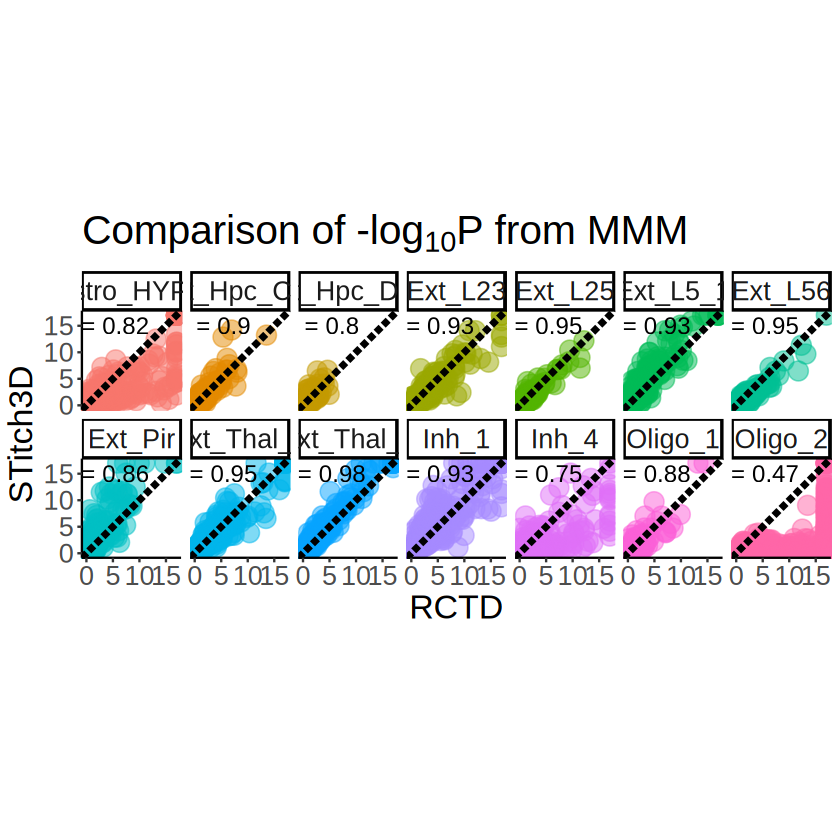

In [21]:
p <- ggplot(pvalues_merge, aes(x = minus_log10_pvalue_RCTD, y = minus_log10_pvalue_ST)) +
    geom_point(aes(color = celltype), size = 5, alpha = 0.5) +
    geom_abline(slope = 1, intercept = 0, linetype = "longdash", color = "black", linewidth = 1.5) +
    geom_text(
        data = correlations,
        mapping = aes(
            x = 4, y = 15,
            label = paste("r =", round(correlation, 2))
        ),
        size = 5
    ) +
    scale_x_continuous(limits = c(0, 17), oob = scales::oob_squish) +
    scale_y_continuous(limits = c(0, 17), oob = scales::oob_squish) +
    coord_fixed(ratio = 1) +
    labs(
        title = expression(paste("Comparison of ", "-log"[10], plain("P"), " from MMM")),
        x = "RCTD", y = "STitch3D"
    ) +
    facet_wrap(celltype ~ ., nrow = 2) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "none"
    )
ggsave(
    file.path(RESULT_PATH, "visium_1", "MMM_RCTD_vs_STitch3D.pdf"),
    plot = p,
    width = 15, height = 6
)
ggsave(
    file.path(RESULT_PATH, "visium_1", "MMM_RCTD_vs_STitch3D.png"),
    plot = p,
    width = 15, height = 6
)
p

### Detailed comparison of Oligo_2

In [22]:
# mcube_object_RCTD_1 <- readRDS(
#     file = file.path(
#         RESULT_PATH, "visium_1",
#         paste0("mcube_RCTD", ".rds")
#     )
# )
# mcube_object_ST_1 <- readRDS(
#     file = file.path(
#         RESULT_PATH, "visium_1",
#         paste0("mcube_ST", ".rds")
#     )
# )

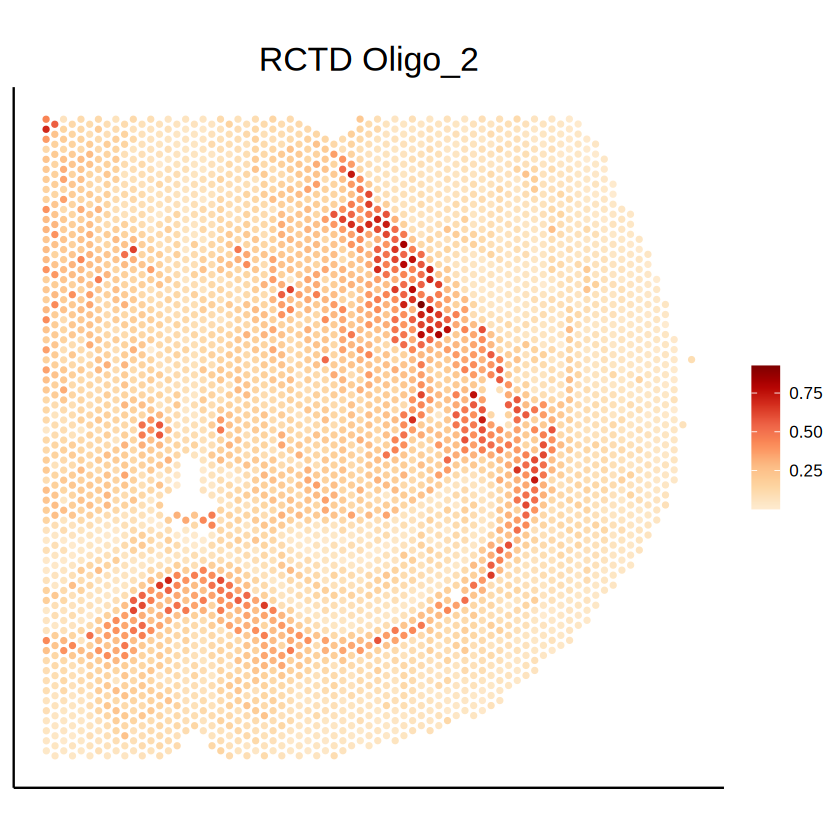

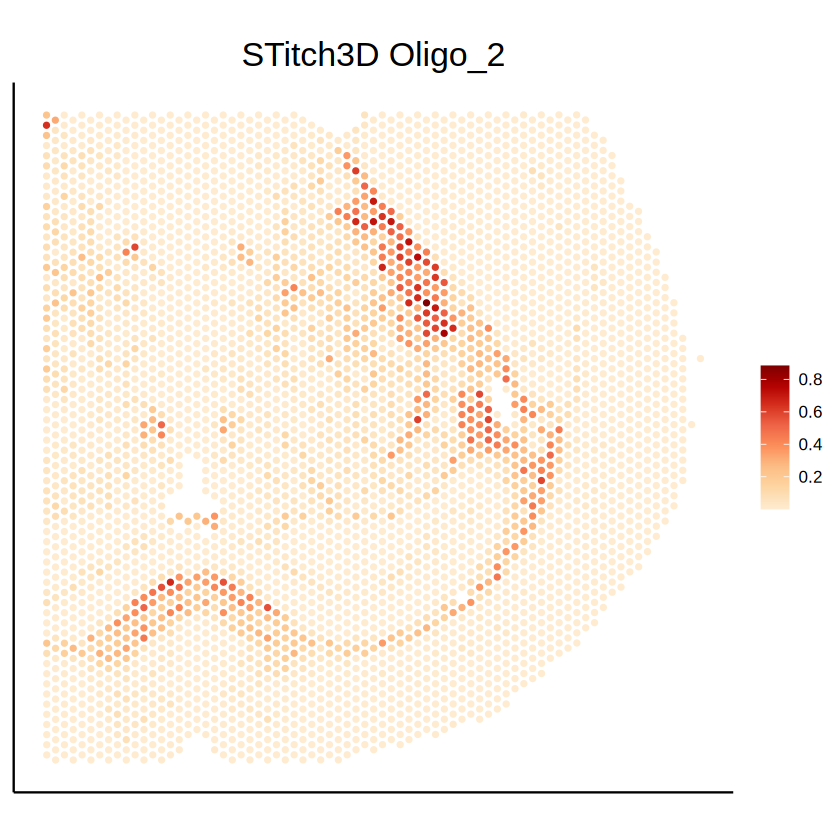

In [23]:
celltype <- "Oligo_2"

p1 <- mcubePlotPropCellType(mcube_object_RCTD_1@proportions, mcube_object_RCTD_1@coordinates, celltype) +
    labs(title = paste("RCTD", celltype)) +
    theme(
        text = element_text(size = 1, hjust = 0.5),
        plot.title = element_text(size = 20, hjust = 0.5),
        axis.title = element_blank(),
        axis.text.x = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks = element_blank(),
        legend.text = element_text(size = 10),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, paste0("proportion_", celltype, "_RCTD", ".pdf")),
    plot = p1, width = 4, height = 4
)

p2 <- mcubePlotPropCellType(mcube_object_ST_1@proportions, mcube_object_ST_1@coordinates, celltype) +
    labs(title = paste("STitch3D", celltype)) +
    theme(
        text = element_text(size = 1, hjust = 0.5),
        plot.title = element_text(size = 20, hjust = 0.5),
        axis.title = element_blank(),
        axis.text.x = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks = element_blank(),
        legend.text = element_text(size = 10),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, paste0("proportion_", celltype, "_STitch3D", ".pdf")),
    plot = p2, width = 4, height = 4
)

p1
p2

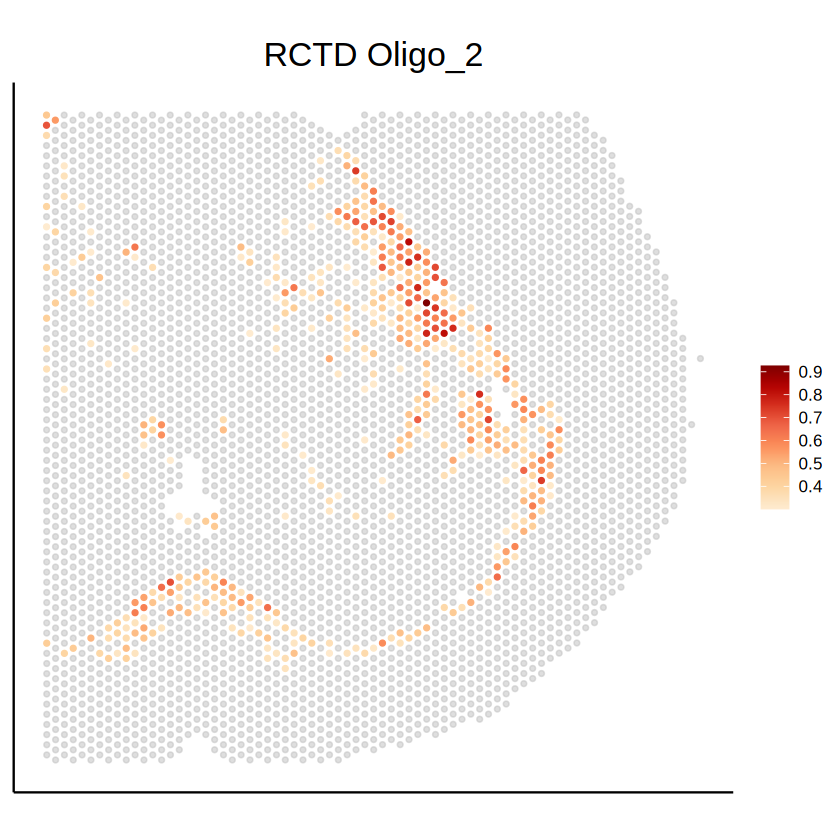

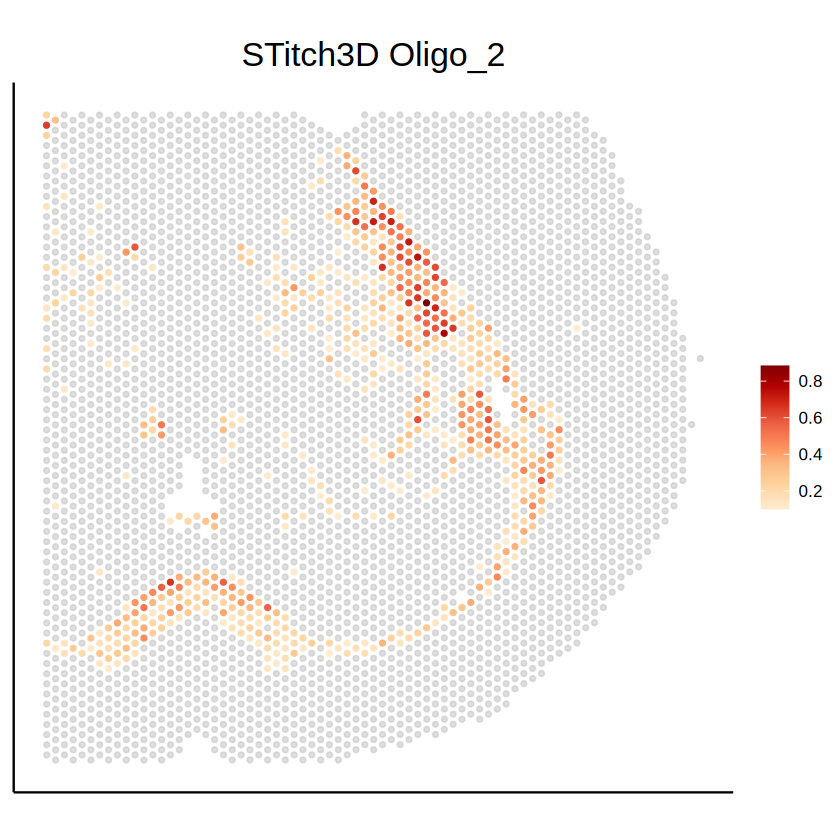

In [24]:
p1 <- mcubePlotPropCellType(
    mcube_object_RCTD_1@proportions, mcube_object_RCTD_1@coordinates, celltype,
    background = TRUE, proportion_threshold = 0.3
) +
labs(title = paste("RCTD", celltype)) +
    theme(
        text = element_text(size = 1, hjust = 0.5),
        plot.title = element_text(size = 20, hjust = 0.5),
        axis.title = element_blank(),
        axis.text.x = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks = element_blank(),
        legend.text = element_text(size = 10),
        legend.position = "right"
    )
ggsave(
    filename = file.path(
        RESULT_PATH, "visium_1",
        paste0("proportion_", celltype, "_region_RCTD", ".pdf")
    ),
    plot = p1, width = 4, height = 4
)
p2 <- mcubePlotPropCellType(
    mcube_object_ST_1@proportions, mcube_object_ST_1@coordinates, 
    celltype, background = TRUE) +
    labs(title = paste("STitch3D", celltype)) +
        theme(
            text = element_text(size = 1, hjust = 0.5),
            plot.title = element_text(size = 20, hjust = 0.5),
            axis.title = element_blank(),
            axis.text.x = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks = element_blank(),
            legend.text = element_text(size = 10),
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH, "visium_1",
        paste0("proportion_", celltype, "_region_STitch3D", ".pdf")
    ),
    plot = p2, width = 4, height = 4
)
p1
p2

In [25]:
mcube_region_RCTD <- createMCube(
    counts = t(as.matrix(myRCTD@originalSpatialRNA@counts[, spot_names])),
    coordinates = as.matrix(myRCTD@spatialRNA@coords),
    proportions = weights_RCTD / rowSums(weights_RCTD),
    library_sizes = myRCTD@spatialRNA@nUMI,
    reference = t(myRCTD@cell_type_info$info[[1]]),
    used_for_deconvolution = rownames(myRCTD@spatialRNA@counts),
    spot_effects = spot_effects_RCTD,
    celltype_test = "Oligo_2",
    celltype_threshold = 50, proportion_threshold = 0.3,
    project = "mouse_brain_visium_1"
)
mcube_region_RCTD <- mcubeFitNull(
    mcube_region_RCTD,
    num_workers = 36, num_threads = 1
)
mcube_region_RCTD <- mcubeTest(
    mcube_region_RCTD,
    num_workers = 36, num_threads = 1, shared_memory = TRUE
)

The batch_id is not provided!
All spots are assumed to be from the same batch and share the same gene platform effects.

Select high-abundance cell types to analyze with proportion_threshold = 0.3 and celltype_threshold = 50.

mcubeFilterCellTypes: Cell type(s) Ext_L23, Oligo_2, Inh_1, Ext_Thal_1, Ext_L56, Ext_Thal_2, Ext_Hpc_DG1, Ext_Hpc_CA1 pass the threshold.

Cell type(s) Oligo_2 will be analyzed.

Filter out lowly-expressed genes with gene_threshold = 5e-05.

mcubeFilterGenes: 2768 genes pass the threshold.

The platform effects are not provided and need to be estimated from data!

Select highly-expressed genes to analyze for each specific cell type with reference_threshold = 0.5.

mcubeFilterGenesCellType: Select 1347 genes to analyze for Oligo_2.

Preprocessed data description: 4167 spots and 58 cell types in total. 483 spots, 1347 genes, and 1 cell type(s) to analyze.

Number of physical cores: 40.

Number of workers: 36.

Number of thread(s) on BLAS per worker: 1.

mcubeKernel

In [26]:
mcube_region_ST <- createMCube(
    counts = counts,
    coordinates = coordinates,
    proportions = proportions_ST,
    library_sizes = library_sizes_ST,
    reference = reference_ST,
    spot_effects = spot_effects_ST,
    celltype_test = "Oligo_2",
    celltype_threshold = 50,
    project = "mouse_brain_visium_1"
)
mcube_region_ST <- mcubeFitNull(
    mcube_region_ST,
    num_workers = 36, num_threads = 1
)
mcube_region_ST <- mcubeTest(
    mcube_region_ST,
    num_workers = 36, num_threads = 1, shared_memory = TRUE
)

The batch_id is not provided!
All spots are assumed to be from the same batch and share the same gene platform effects.

Select high-abundance cell types to analyze with proportion_threshold = 0.1 and celltype_threshold = 50.

mcubeFilterCellTypes: Cell type(s) Astro_HYPO, Ext_Amy_2, Ext_Hpc_CA1, Ext_Hpc_DG1, Ext_L23, Ext_L25, Ext_L56, Ext_L5_1, Ext_L5_2, Ext_Pir, Ext_Thal_1, Ext_Thal_2, Ext_Unk_3, Inh_1, Inh_2, Inh_3, Inh_4, Oligo_1, Oligo_2 pass the threshold.

Cell type(s) Oligo_2 will be analyzed.

Filter out lowly-expressed genes with gene_threshold = 5e-05.

mcubeFilterGenes: 2599 genes pass the threshold.

The platform effects are not provided and need to be estimated from data!

Select highly-expressed genes to analyze for each specific cell type with reference_threshold = 0.5.

mcubeFilterGenesCellType: Select 991 genes to analyze for Oligo_2.

Preprocessed data description: 4168 spots and 58 cell types in total. 628 spots, 991 genes, and 1 cell type(s) to analyze.

Number of 

In [27]:
mcube_pvalues_region_RCTD <- mcubePvalueList2LongTable(mcube_region_RCTD@pvalues)
mcube_pvalues_region_RCTD$minus_log10_pvalue <- -log10(mcube_pvalues_region_RCTD$pvalue)
mcube_pvalues_region_RCTD$minus_log10_pvalue[mcube_pvalues_region_RCTD$minus_log10_pvalue > 17] <- 17
mcube_pvalues_region_ST <- mcubePvalueList2LongTable(mcube_region_ST@pvalues)
mcube_pvalues_region_ST$minus_log10_pvalue <- -log10(mcube_pvalues_region_ST$pvalue)
mcube_pvalues_region_ST$minus_log10_pvalue[mcube_pvalues_region_ST$minus_log10_pvalue > 17] <- 17
pvalues_merge <- merge(
    mcube_pvalues_region_RCTD, mcube_pvalues_region_ST,
    by = c("celltype", "gene"),
    suffixes = c("_RCTD", "_ST")
)
head(pvalues_merge)

,celltype,gene,pvalue_RCTD,minus_log10_pvalue_RCTD,pvalue_ST,minus_log10_pvalue_ST
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Oligo_2,1110004F10Rik,0.01716477,1.76536211,1.537800e-01,0.8131003
2,Oligo_2,1110051M20Rik,0.01430794,1.84442276,3.843169e-02,1.4153105
3,Oligo_2,1700025G04Rik,0.54033421,0.26733754,4.166653e-01,0.3802126
4,Oligo_2,4930402H24Rik,0.01426273,1.84579720,1.176651e-05,4.9293522
5,Oligo_2,4931406P16Rik,0.87411995,0.05842897,5.004367e-01,0.3006508
6,Oligo_2,4933431E20Rik,0.15644749,0.80563139,4.845538e-02,1.3146580


In [28]:
correlation <- cor(
    pvalues_merge$minus_log10_pvalue_RCTD, pvalues_merge$minus_log10_pvalue_ST,
    method = "pearson"
)

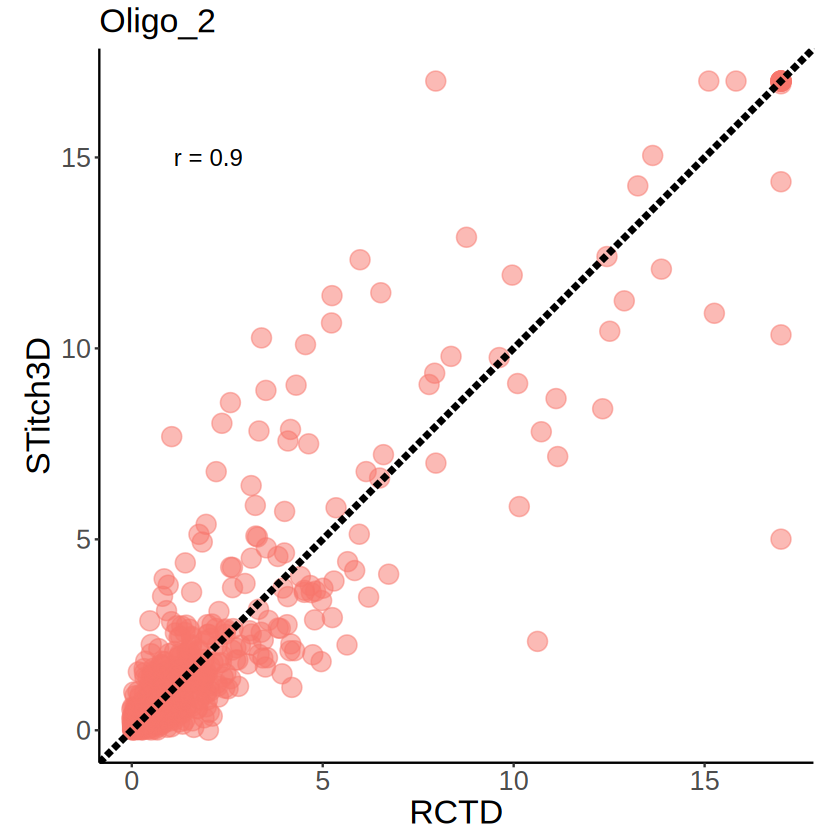

In [29]:
p <- ggplot(pvalues_merge, aes(x = minus_log10_pvalue_RCTD, y = minus_log10_pvalue_ST)) +
  geom_point(aes(color = celltype), size = 5, alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "longdash", color = "black", linewidth = 1.5) +
  annotate(
    "text",
    label = paste("r =", round(correlation, 2)),
    x = 2, y = 15, size = 5
  ) +
    scale_x_continuous(limits = c(0, 17), oob = scales::oob_squish) +
    scale_y_continuous(limits = c(0, 17), oob = scales::oob_squish) +
    coord_fixed(ratio = 1) +
    labs(
        title = celltype,
        x = "RCTD", y = "STitch3D"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 20),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20),
        legend.position = "none"
    )
ggsave(
  file.path(RESULT_PATH, "visium_1", "MMM_Oligo_2_RCTD_vs_STitch3D.pdf"),
  plot = p,
  width = 4, height = 4
)
p

In [30]:
rm(mcube_object_RCTD_1, mcube_object_ST_1)

## Visium Slice 2

In [31]:
counts <- as.data.frame(readr::read_csv(
    file.path(RAW_DATA_PATH, "visium_2", "counts.csv")
))
rownames(counts) <- counts[, 1]
counts[, 1] <- NULL
counts <- as.matrix(counts)
dim(counts)

coordinates <- as.data.frame(readr::read_csv(
    file.path(RAW_DATA_PATH, "visium_2", "3D_coordinates.csv")
))
rownames(coordinates) <- coordinates[, 1]
coordinates[, c(1, 4)] <- NULL
coordinates <- as.matrix(coordinates)
dim(coordinates)

puck <- SpatialRNA(as.data.frame(coordinates), t(counts), rowSums(counts))

New names:
• `` -> `...1`
Rows: 3925 Columns: 6416
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr    (1): ...1
dbl (6415): 0610040J01Rik, 0610043K17Rik, 1110002J07Rik, 1110004F10Rik, 1110...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 3925 6415

New names:
• `` -> `...1`
Rows: 3925 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): ...1
dbl (3): x, y, z

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 3925    2

### Integrating with `RCTD`

#### Cell type deconvolution

In [32]:
# minor_celltypes <- names(which(table(sc_labels) < 25))
myRCTD <- create.RCTD(
    puck, reference,
    CELL_MIN_INSTANCE = 20, max_cores = 8
)
myRCTD <- run.RCTD(myRCTD, doublet_mode = "full")
saveRDS(myRCTD, file.path(RESULT_PATH, "visium_2", "myRCTD.rds"))
# myRCTD <- readRDS(file.path(RESULT_PATH, "visium_2", "myRCTD.rds"))

Begin: process_cell_type_info

process_cell_type_info: number of cells in reference: 38849

process_cell_type_info: number of genes in reference: 6415




       Ext_L23        Oligo_2 Astro_THAL_med        Inh_Sst          Inh_6 
          1244          10000            405            640            467 
      Ext_L5_3    Inh_Meis2_3          Micro       Ext_L5_2        Ext_Pir 
           127            789           1218            166            954 
     Astro_AMY          Inh_2          Inh_1      Inh_Pvalb      Inh_Lamp5 
           498            839            573            804            331 
       Ext_L25           Nb_2     Ext_Thal_1        Ext_L56      Ext_Unk_2 
           922            203           1197           1422            205 
     Ext_Unk_3          Inh_3      Ext_Amy_2     Ext_Thal_2       Ext_L5_1 
           416            818            797            671            893 
         OPC_1  Astro_AMY_CTX    Ext_Hpc_DG1     Astro_HYPO          Inh_4 
          1015            279            554            451           1389 
   Inh_Meis2_1    Ext_Hpc_DG2        Ext_Med    Inh_Meis2_2    Ext_Hpc_CA1 
           

End: process_cell_type_info

create.RCTD: getting regression differentially expressed genes: 

get_de_genes: Ext_L23 found DE genes: 112

get_de_genes: Oligo_2 found DE genes: 408

get_de_genes: Astro_THAL_med found DE genes: 353

get_de_genes: Inh_Sst found DE genes: 123

get_de_genes: Inh_6 found DE genes: 195

get_de_genes: Ext_L5_3 found DE genes: 133

get_de_genes: Inh_Meis2_3 found DE genes: 153

get_de_genes: Micro found DE genes: 647

get_de_genes: Ext_L5_2 found DE genes: 102

get_de_genes: Ext_Pir found DE genes: 69

get_de_genes: Astro_AMY found DE genes: 333

get_de_genes: Inh_2 found DE genes: 99

get_de_genes: Inh_1 found DE genes: 86

get_de_genes: Inh_Pvalb found DE genes: 132

get_de_genes: Inh_Lamp5 found DE genes: 167

get_de_genes: Ext_L25 found DE genes: 147

get_de_genes: Nb_2 found DE genes: 364

get_de_genes: Ext_Thal_1 found DE genes: 212

get_de_genes: Ext_L56 found DE genes: 157

get_de_genes: Ext_Unk_2 found DE genes: 150

get_de_genes: Ext_Unk_3 found DE ge

In [33]:
write.table(
    rownames(myRCTD@spatialRNA@counts),
    file = file.path(
        DATA_PATH, "visium_2",
        paste0("HVG_RCTD", ".csv")
    ),
    quote = FALSE, row.names = FALSE, col.names = FALSE
)

In [34]:
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)

proportions_filter <- proportions_RCTD
proportions_filter[proportions_filter < 0.1] <- 0
major_celltypes <- colnames(proportions_filter)[
    which(colSums(proportions_filter) > 50)
]

proportions_RCTD_long_2 <- proportions_RCTD[, major_celltypes] %>%
  cbind(myRCTD@spatialRNA@coords) %>%
  tidyr::pivot_longer(
    cols = -(x:y),
    names_to = "Cell type",
    values_to = "Proportion"
  )
head(proportions_RCTD_long_2)

x,y,Cell type,Proportion
<dbl>,<dbl>,<chr>,<dbl>
4359.614,5109.826,Ext_L23,1.971831e-05
4359.614,5109.826,Oligo_2,7.585819e-02
4359.614,5109.826,Inh_1,1.971831e-05
4359.614,5109.826,Ext_L25,5.911649e-02
4359.614,5109.826,Ext_Thal_1,1.971831e-05
4359.614,5109.826,Ext_L56,1.298476e-01


In [35]:
p <- ggplot(proportions_RCTD_long_2, aes(x = x, y = y)) +
    geom_point(aes(color = Proportion), size = 1, alpha = 1) +
    scale_colour_gradientn(name = NULL, colors = pals::brewer.orrd(22)[3:22]) +
    scale_y_continuous(trans = "reverse") +
    coord_fixed(ratio = 1) +
    facet_wrap(~`Cell type`, ncol = 6) +
    labs(
        title = "Estimated cell type proportions by RCTD",
        x = "x", y = "y"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24, hjust = 0.5),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, "visium_2", "proportions_RCTD.pdf"),
    plot = p, width = 16, height = 9
)

#### Identifying cell-type-specific SVGs using `MCube`

In [36]:
spot_names <- colnames(myRCTD@spatialRNA@counts)
weights_RCTD <- as.matrix(myRCTD@results$weights)
spot_effects_RCTD <- log(rowSums(weights_RCTD))
names(spot_effects_RCTD) <- rownames(weights_RCTD)

In [37]:
mcube_object_RCTD_2 <- createMCube(
    counts = t(as.matrix(myRCTD@originalSpatialRNA@counts[, spot_names])),
    coordinates = as.matrix(myRCTD@spatialRNA@coords),
    proportions = weights_RCTD / rowSums(weights_RCTD),
    library_sizes = myRCTD@spatialRNA@nUMI,
    reference = t(myRCTD@cell_type_info$info[[1]]),
    used_for_deconvolution = rownames(myRCTD@spatialRNA@counts),
    spot_effects = spot_effects_RCTD,
    celltype_test = grep("Unk|LowQ", levels(sc_labels), value = TRUE, invert = TRUE),
    celltype_threshold = 50,
    project = "mouse_brain_visium_2"
)
mcube_object_RCTD_2 <- mcubeFitNull(
    mcube_object_RCTD_2,
    num_workers = 36, num_threads = 1
)
mcube_object_RCTD_2 <- mcubeTest(
    mcube_object_RCTD_2,
    num_workers = 36, num_threads = 1, shared_memory = TRUE
)

saveRDS(
    mcube_object_RCTD_2,
    file = file.path(
        RESULT_PATH, "visium_2",
        paste0("mcube_RCTD", ".rds")
    )
)
saveRDS(
    mcube_object_RCTD_2@pvalues,
    file = file.path(
        RESULT_PATH, "visium_2",
        paste0("mcube_pvalues_RCTD", ".rds")
    )
)
rm(mcube_object_RCTD_2)

# mcube_pvalues_RCTD_2 <- readRDS(
#     file = file.path(
#         RESULT_PATH, "visium_2",
#         paste0("mcube_pvalues_RCTD", ".rds")
#     )
# )

The batch_id is not provided!
All spots are assumed to be from the same batch and share the same gene platform effects.

Select high-abundance cell types to analyze with proportion_threshold = 0.1 and celltype_threshold = 50.

mcubeFilterCellTypes: Cell type(s) Ext_L23, Oligo_2, Inh_1, Ext_L25, Ext_Thal_1, Ext_L56, Ext_Thal_2, Ext_L5_1, Ext_Hpc_DG1, Astro_HYPO, Inh_4, Ext_Med, Ext_Hpc_CA1, Oligo_1, Astro_HPC pass the threshold.

Cell type(s) Astro_THAL_med, Inh_Sst, Inh_6, Ext_L5_3, Inh_Meis2_3, Micro, Ext_L5_2, Ext_Pir, Astro_AMY, Inh_2, Inh_Pvalb, Inh_Lamp5, Nb_2, Inh_3, Ext_Amy_2, OPC_1, Astro_AMY_CTX, Inh_Meis2_1, Ext_Hpc_DG2, Inh_Meis2_2, Ext_L6B, Astro_CTX, Ext_Amy_1, Astro_WM, Astro_STR, Ext_L6, Astro_THAL_lat, Nb_1, Inh_Vip, Ext_ClauPyr, Ext_Hpc_CA2, OPC_2, Inh_5, Ext_Hpc_CA3, Inh_Meis2_4, Astro_THAL_hab, Endo has/have less than the minimum celltype_threshold = 50 with proportion_threshold = 0.1.
To include the above cell type(s), please reduce celltype_threshold or proportion_

### Integrating with `STitch3D`

#### Load in deconvolution results

In [38]:
reference_ST <- data.matrix(read.csv(
    file.path(DATA_PATH, "visium_2", "reference_ST.csv"),
    header = TRUE, row.names = 1, check.names = FALSE
))
dim(reference_ST)
num_celltypes <- nrow(reference_ST)

proportions_ST <- data.matrix(read.csv(
    file.path(DATA_PATH, "visium_2", paste0("prop_slice", 0, ".csv")),
    header = TRUE, row.names = 1, check.names = FALSE
))
dim(proportions_ST)

counts <- as.data.frame(readr::read_csv(
    file.path(DATA_PATH, "visium_2", "counts.csv")
))
rownames(counts) <- counts[, 1]
counts[, 1] <- NULL
counts <- data.matrix(counts)
dim(counts)

coordinates <- data.matrix(read.csv(
    file.path(DATA_PATH, "visium_2", "3D_coordinates.csv"),
    header = TRUE, row.names = 1, check.names = FALSE
))[, c("x", "y")]
dim(coordinates)

spot_effects_ST <- data.matrix(read.csv(
    file.path(DATA_PATH, "visium_2", "spot_effects_ST.csv"),
    header = TRUE, row.names = 1, check.names = FALSE
))[, 1]

library_sizes_ST <- data.matrix(read.csv(
    file.path(DATA_PATH, "visium_2", "library_sizes_ST.csv"),
    header = TRUE, row.names = 1, check.names = FALSE
))[, 1]

[1]   58 4489

[1] 3925   58

New names:
• `` -> `...1`
Rows: 3925 Columns: 4490
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr    (1): ...1
dbl (4489): Xkr4, Sox17, Rgs20, Oprk1, Rb1cc1, St18, Sntg1, Adhfe1, Sgk3, Mc...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 3925 4489

[1] 3925    2

In [39]:
proportions_filter <- proportions_ST
proportions_filter[proportions_filter < 0.1] <- 0
major_celltypes <- colnames(proportions_filter)[
    which(colSums(proportions_filter) > 50)
]

proportions_ST_long_2 <- as.data.frame(proportions_ST[, major_celltypes]) %>%
  cbind(coordinates) %>%
  tidyr::pivot_longer(
    cols = -(x:y),
    names_to = "Cell type",
    values_to = "Proportion"
  )
head(proportions_ST_long_2)

x,y,Cell type,Proportion
<dbl>,<dbl>,<chr>,<dbl>
4359.614,5109.826,Astro_HYPO,1.179485e-06
4359.614,5109.826,Ext_Amy_2,7.797921e-05
4359.614,5109.826,Ext_Hpc_CA1,1.753935e-04
4359.614,5109.826,Ext_Hpc_DG1,1.280550e-07
4359.614,5109.826,Ext_L23,1.618132e-04
4359.614,5109.826,Ext_L25,6.004004e-02


In [40]:
p <- ggplot(proportions_ST_long_2, aes(x = x, y = y)) +
    geom_point(aes(color = Proportion), size = 1, alpha = 1) +
    scale_colour_gradientn(name = NULL, colors = pals::brewer.orrd(22)[3:22]) +
    scale_y_continuous(trans = "reverse") +
    coord_fixed(ratio = 1) +
    facet_wrap(~`Cell type`, nrow = 3) +
    labs(
        title = "Estimated cell type proportions by STitch3D",
        x = "x", y = "y"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24, hjust = 0.5),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, "visium_2", "proportions_STitch3D.pdf"),
    plot = p, width = 16, height = 9
)

#### Identifying cell-type-specific SVGs using `MCube`

In [41]:
mcube_object_ST_2 <- createMCube(
    counts = counts,
    coordinates = coordinates,
    proportions = proportions_ST,
    library_sizes = library_sizes_ST,
    reference = reference_ST,
    spot_effects = spot_effects_ST,
    celltype_test = grep("Unk|LowQ", levels(sc_labels), value = TRUE, invert = TRUE),
    celltype_threshold = 50,
    project = "mouse_brain_visium_2"
)
mcube_object_ST_2 <- mcubeFitNull(
    mcube_object_ST_2,
    num_workers = 36, num_threads = 1
)
mcube_object_ST_2 <- mcubeTest(
    mcube_object_ST_2,
    num_workers = 36, num_threads = 1, shared_memory = TRUE
)

saveRDS(
    mcube_object_ST_2,
    file = file.path(
        RESULT_PATH, "visium_2",
        paste0("mcube_ST", ".rds")
    )
)
saveRDS(
    mcube_object_ST_2@pvalues,
    file = file.path(
        RESULT_PATH, "visium_2",
        paste0("mcube_pvalues_ST", ".rds")
    )
)
rm(mcube_object_ST_2)

# mcube_pvalues_ST_2 <- readRDS(
#     file = file.path(
#         RESULT_PATH, "sensitivity", "visium_2",
#         paste0("mcube_pvalues_ST", ".rds")
#     )
# )

The batch_id is not provided!
All spots are assumed to be from the same batch and share the same gene platform effects.

Select high-abundance cell types to analyze with proportion_threshold = 0.1 and celltype_threshold = 50.

mcubeFilterCellTypes: Cell type(s) Astro_HYPO, Ext_Amy_2, Ext_Hpc_CA1, Ext_Hpc_DG1, Ext_L23, Ext_L25, Ext_L56, Ext_L5_1, Ext_L5_2, Ext_Med, Ext_Thal_1, Ext_Thal_2, Ext_Unk_3, Inh_1, Inh_2, Inh_3, Inh_4, Oligo_1, Oligo_2 pass the threshold.

Cell type(s) Astro_AMY, Astro_AMY_CTX, Astro_CTX, Astro_HPC, Astro_STR, Astro_THAL_hab, Astro_THAL_lat, Astro_THAL_med, Astro_WM, Endo, Ext_Amy_1, Ext_ClauPyr, Ext_Hpc_CA2, Ext_Hpc_CA3, Ext_Hpc_DG2, Ext_L5_3, Ext_L6, Ext_L6B, Ext_Pir, Inh_5, Inh_6, Inh_Lamp5, Inh_Meis2_1, Inh_Meis2_2, Inh_Meis2_3, Inh_Meis2_4, Inh_Pvalb, Inh_Sst, Inh_Vip, Micro, Nb_1, Nb_2, OPC_1, OPC_2 has/have less than the minimum celltype_threshold = 50 with proportion_threshold = 0.1.
To include the above cell type(s), please reduce celltype_threshold or 

### Comparison of the deconvolution results

In [42]:
overlap_celltypes <- intersect(
    unique(proportions_RCTD_long_2$`Cell type`),
    unique(proportions_ST_long_2$`Cell type`)
)
overlap_celltypes <- sort(overlap_celltypes)
overlap_celltypes

[1] "Astro_HYPO"  "Ext_Hpc_CA1" "Ext_Hpc_DG1" "Ext_L23"     "Ext_L25"    
 [6] "Ext_L5_1"    "Ext_L56"     "Ext_Med"     "Ext_Thal_1"  "Ext_Thal_2" 
[11] "Inh_1"       "Inh_4"       "Oligo_1"     "Oligo_2"

In [43]:
p <- ggplot(
    proportions_RCTD_long_2[proportions_RCTD_long_2$`Cell type` %in% overlap_celltypes, ],
    aes(x = x, y = y)
) +
    geom_point(aes(color = Proportion), size = 1, alpha = 1) +
    scale_colour_gradientn(name = NULL, colors = pals::brewer.orrd(22)[3:22]) +
    scale_y_continuous(trans = "reverse") +
    coord_fixed(ratio = 1) +
    facet_wrap(~`Cell type`, nrow = 2) +
    labs(
        title = "Estimated cell type proportions by RCTD",
        x = "x", y = "y"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24, hjust = 0.5),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, "visium_2", "sensitivity_proportions_RCTD.pdf"),
    plot = p, width = 16, height = 6
)

In [44]:
p <- ggplot(
    proportions_ST_long_2[proportions_ST_long_2$`Cell type` %in% overlap_celltypes, ],
    aes(x = x, y = y)
) +
    geom_point(aes(color = Proportion), size = 1, alpha = 1) +
    scale_colour_gradientn(name = NULL, colors = pals::brewer.orrd(22)[3:22]) +
    scale_y_continuous(trans = "reverse") +
    coord_fixed(ratio = 1) +
    facet_wrap(~`Cell type`, nrow = 2) +
    labs(
        title = "Estimated cell type proportions by STitch3D",
        x = "x", y = "y"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24, hjust = 0.5),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, "visium_2", "sensitivity_proportions_STitch3D.pdf"),
    plot = p, width = 16, height = 6
)

### Comparison of the cell-type-specific SVG results

In [45]:
mcube_pvalues_RCTD_2 <- readRDS(
    file = file.path(
        RESULT_PATH, "visium_2",
        paste0("mcube_pvalues_RCTD", ".rds")
    )
)
mcube_pvalues_ST_2 <- readRDS(
    file = file.path(
        RESULT_PATH, "visium_2",
        paste0("mcube_pvalues_ST", ".rds")
    )
)

In [46]:
mcube_pvalues_RCTD_2 <- mcubePvalueList2LongTable(mcube_pvalues_RCTD_2)
mcube_pvalues_RCTD_2$minus_log10_pvalue <- -log10(mcube_pvalues_RCTD_2$pvalue)
mcube_pvalues_RCTD_2$minus_log10_pvalue[mcube_pvalues_RCTD_2$minus_log10_pvalue > 17] <- 17
mcube_pvalues_ST_2 <- mcubePvalueList2LongTable(mcube_pvalues_ST_2)
mcube_pvalues_ST_2$minus_log10_pvalue <- -log10(mcube_pvalues_ST_2$pvalue)
mcube_pvalues_ST_2$minus_log10_pvalue[mcube_pvalues_ST_2$minus_log10_pvalue > 17] <- 17
pvalues_merge <- merge(
    mcube_pvalues_RCTD_2, mcube_pvalues_ST_2,
    by = c("celltype", "gene"),
    suffixes = c("_RCTD", "_ST")
)
head(pvalues_merge)

,celltype,gene,pvalue_RCTD,minus_log10_pvalue_RCTD,pvalue_ST,minus_log10_pvalue_ST
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Astro_HYPO,1110004F10Rik,0.001278629,2.89325554,0.03689844,1.4329920
2,Astro_HYPO,1110051M20Rik,0.010943041,1.96086199,0.07129424,1.1469455
3,Astro_HYPO,2310022B05Rik,0.902371928,0.04461442,0.33203934,0.4788105
4,Astro_HYPO,2700081O15Rik,0.157050125,0.80396171,0.31020245,0.5083548
5,Astro_HYPO,4930402H24Rik,0.716225347,0.14495031,0.38755751,0.4116638
6,Astro_HYPO,4933431E20Rik,0.617446854,0.20940042,0.37551396,0.4253739


In [47]:
correlations <- pvalues_merge %>%
    group_by(celltype) %>%
    summarize(
        correlation = cor(minus_log10_pvalue_RCTD, minus_log10_pvalue_ST, method = "pearson")
    )

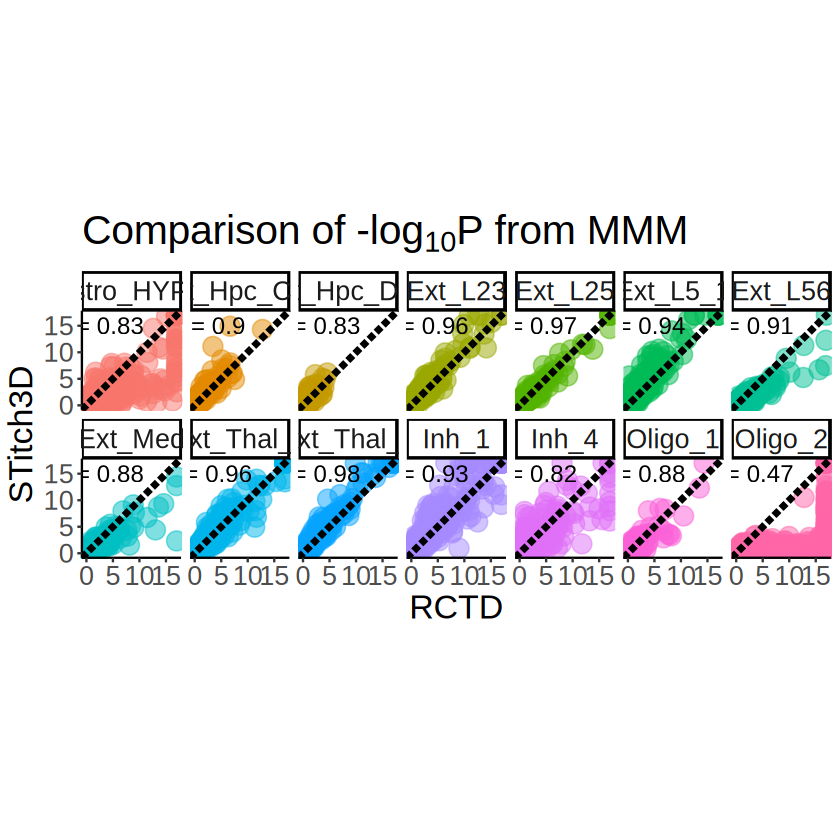

In [48]:
p <- ggplot(pvalues_merge, aes(x = -log10(pvalue_RCTD), y = -log10(pvalue_ST))) +
    geom_point(aes(color = celltype), size = 5, alpha = 0.5) +
    geom_abline(slope = 1, intercept = 0, linetype = "longdash", color = "black", linewidth = 1.5) +
    geom_text(
        data = correlations,
        mapping = aes(
            x = 3, y = 15,
            label = paste("r =", round(correlation, 2))
        ),
        size = 5
    ) +
    scale_x_continuous(limits = c(0, 17), oob = scales::oob_squish) +
    scale_y_continuous(limits = c(0, 17), oob = scales::oob_squish) +
    coord_fixed(ratio = 1) +
    labs(
        title = expression(paste("Comparison of ", "-log"[10], plain("P"), " from MMM")),
        x = "RCTD", y = "STitch3D"
    ) +
    facet_wrap(celltype ~ ., nrow = 2) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "none"
    )
ggsave(
    file.path(RESULT_PATH, "visium_2", "MMM_RCTD_vs_STitch3D.pdf"),
    plot = p,
    width = 15, height = 6
)
ggsave(
    file.path(RESULT_PATH, "visium_2", "MMM_RCTD_vs_STitch3D.png"),
    plot = p,
    width = 15, height = 6
)
p

## Replicability analysis of `MCube` using the two slices

### Comparison of the deconvolution results from `RCTD` on the two slices

In [49]:
overlap_celltypes <- intersect(
    unique(proportions_RCTD_long_1$`Cell type`),
    unique(proportions_RCTD_long_2$`Cell type`)
)
overlap_celltypes <- sort(overlap_celltypes)
overlap_celltypes

[1] "Astro_HPC"   "Astro_HYPO"  "Ext_Hpc_CA1" "Ext_Hpc_DG1" "Ext_L23"    
 [6] "Ext_L25"     "Ext_L5_1"    "Ext_L56"     "Ext_Med"     "Ext_Thal_1" 
[11] "Ext_Thal_2"  "Inh_1"       "Inh_4"       "Oligo_1"     "Oligo_2"

In [50]:
p <- ggplot(
    proportions_RCTD_long_1[proportions_RCTD_long_1$`Cell type` %in% overlap_celltypes, ],
    aes(x = x, y = y)
) +
    geom_point(aes(color = Proportion), size = 1, alpha = 1) +
    scale_colour_gradientn(name = NULL, colors = pals::brewer.orrd(22)[3:22]) +
    scale_y_continuous(trans = "reverse") +
    coord_fixed(ratio = 1) +
    facet_wrap(~`Cell type`, nrow = 2) +
    labs(
        title = "Estimated cell type proportions by RCTD on Slice 1",
        x = "x", y = "y"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24, hjust = 0.5),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, "visium_1", "replicability_proportions_RCTD.pdf"),
    plot = p, width = 20, height = 6
)

In [51]:
p <- ggplot(
    proportions_RCTD_long_2[proportions_RCTD_long_2$`Cell type` %in% overlap_celltypes, ],
    aes(x = x, y = y)
) +
    geom_point(aes(color = Proportion), size = 1, alpha = 1) +
    scale_colour_gradientn(name = NULL, colors = pals::brewer.orrd(22)[3:22]) +
    scale_y_continuous(trans = "reverse") +
    coord_fixed(ratio = 1) +
    facet_wrap(~`Cell type`, nrow = 2) +
    labs(
        title = "Estimated cell type proportions by RCTD on Slice 2",
        x = "x", y = "y"
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24, hjust = 0.5),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "right"
    )
ggsave(
    filename = file.path(RESULT_PATH, "visium_2", "replicability_proportions_RCTD.pdf"),
    plot = p, width = 20, height = 6
)

### Comparison of the cell-type-specific SVG results on the two slices

In [52]:
pvalues_merge <- merge(
    mcube_pvalues_RCTD_1, mcube_pvalues_RCTD_2,
    by = c("celltype", "gene"),
    suffixes = c("_slice1", "_slice2")
)
head(pvalues_merge)

,celltype,gene,pvalue_slice1,minus_log10_pvalue_slice1,pvalue_slice2,minus_log10_pvalue_slice2
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Astro_HPC,1110004F10Rik,0.16333938,0.7869091,0.33869033,0.47019720
2,Astro_HPC,1110051M20Rik,0.11299529,0.9469396,0.09168947,1.03768056
3,Astro_HPC,2700081O15Rik,0.02374883,1.6243577,0.07037821,1.15256181
4,Astro_HPC,4930402H24Rik,0.60270832,0.2198928,0.87571766,0.05763589
5,Astro_HPC,4932438A13Rik,0.17432673,0.7586360,0.40611553,0.39135040
6,Astro_HPC,4933431E20Rik,0.63832126,0.1949607,0.47503713,0.32327244


In [53]:
correlations <- pvalues_merge %>%
    group_by(celltype) %>%
    summarize(
        correlation = cor(minus_log10_pvalue_slice1, minus_log10_pvalue_slice2, method = "pearson")
    )

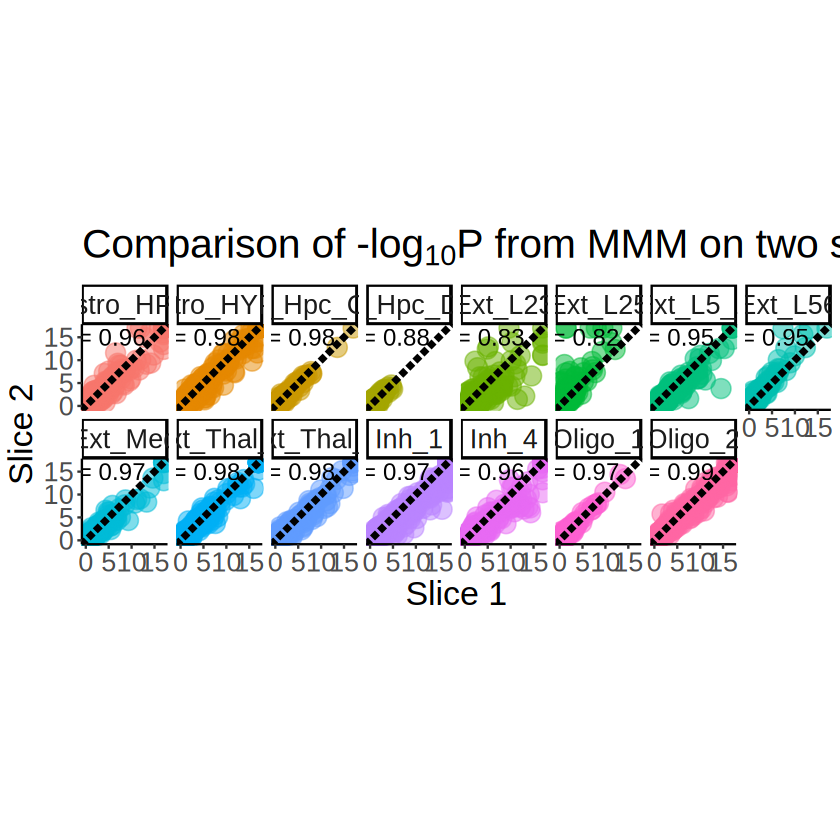

In [54]:
p <- ggplot(pvalues_merge, aes(x = minus_log10_pvalue_slice1, y = minus_log10_pvalue_slice2)) +
    geom_point(aes(color = celltype), size = 5, alpha = 0.5) +
    geom_abline(slope = 1, intercept = 0, linetype = "longdash", color = "black", linewidth = 1.5) +
    geom_text(
        data = correlations,
        mapping = aes(
            x = 4, y = 15,
            label = paste("r =", round(correlation, 2))
        ),
        size = 5
    ) +
    scale_x_continuous(limits = c(0, 17), oob = scales::oob_squish) +
    scale_y_continuous(limits = c(0, 17), oob = scales::oob_squish) +
    coord_fixed(ratio = 1) +
    labs(
        title = expression(paste("Comparison of ", "-log"[10], plain("P"), " from MMM on two slices")),
        x = "Slice 1", y = "Slice 2"
    ) +
    facet_wrap(celltype ~ ., nrow = 2) +
    theme_classic() +
    theme(
        plot.title = element_text(size = 24),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20),
        strip.text = element_text(size = 16),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        legend.position = "none"
    )
ggsave(
    file.path(RESULT_PATH, "mouse_brain_MMM_replicability.pdf"),
    plot = p,
    width = 15, height = 6
)
p